# ML4Net - Lab 1

## Team members

Antoine Metz 335801 | Corentin Le Bris 335776

## Description

In this lab, we work with Multi-Armed Bandits (MABs) for Wi-Fi channel allocation in an Overlapping Basic Service Set (OBSS) scenario. The goal is to first understand the simulator outputs, then compare a classical epsilon-greedy policy with a custom ML4Net action-selection strategy.

## Instructions

- Follow the steps from this notebook and complete the proposed exercises.
- Deliver the completed notebook by uploading it to the GitHub repository.
- Submission deadline: 8 May 2026 (EoB).

## Setting up the environment

### 1. Connect Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Download the simulator source code

In [3]:
!wget -q https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip

### 3. Define the main path

In [4]:
mypath = "drive/MyDrive/AAX/Lab1"

### 4. Extract the source code

In [5]:
!mkdir -p "$mypath"
!cp -f Komondor-lightweight.zip "$mypath"
!cd "$mypath" && unzip -o Komondor-lightweight.zip > /dev/null

### 5. Give permissions to run the code

In [6]:
!sudo apt-get install -y lib32stdc++6 > /dev/null
!cd "$mypath" && chmod -R 777 *

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 3.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


### 6. Compile the code

In [7]:
!cd "$mypath/main" && ./build_local

## How to run simulations

Komondor can be run by calling the compiled file `komondor_main` and passing the required arguments. The simulator reads its input files from the `input` folder and writes output files to the `output` folder. Console logs are also important because they contain the final throughput blocks printed at the end of simulations.

### 1) Simulation without agents

In [8]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

INPUT_FILE_NODES = '../input/input_nodes.csv'
OUTPUT_FILE_LOGS = '../output/logs_test.txt'
SIMULATION_CODE = 'AAX-LAB1'

FLAG_SAVE_NODE_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1

SIM_TIME = 100
SEED = 7

In [9]:
# RUN THE SIMULATION

!cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_test.txt
  - simulation_code: AAX-LAB1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input file '../input/

### 2) Simulation with agents

In [10]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS)

INPUT_FILE_NODES = '../input/input_nodes.csv'
INPUT_FILE_AGENTS = '../input/agents_monitoring.csv'
OUTPUT_FILE_LOGS = '../output/logs_test_agents.txt'
SIMULATION_CODE = 'AAX-LAB1-AGENTS'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 0
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

Run the simulation.

In [11]:
!cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

## Common imports and helper functions

In [12]:
import os
import re
import glob
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# The notebook is designed to run in Google Colab.
# In Colab, `mypath` is normally "drive/MyDrive/AAX/Lab1".
# We convert it to an absolute path because Python functions need real paths.
if mypath.startswith('/'):
    base_path = mypath
else:
    base_path = os.path.join('/content', mypath)

# Main folders used by the simulator.
input_path = os.path.join(base_path, 'input')
output_path = os.path.join(base_path, 'output')
main_output_path = os.path.join(base_path, 'main', 'output')
os.makedirs(output_path, exist_ok=True)

# Komondor can write files in two slightly different places depending on how it is launched:
# - ../output when OUTPUT_FILE_LOGS is passed by argument,
# - main/output for the detailed console logs created internally by the simulator.
# Keeping both paths avoids the "simulation worked but no throughput extracted" problem.
output_roots = [output_path, main_output_path]


def read_csv_auto(path):
    """Read a CSV file while letting pandas infer the separator."""
    return pd.read_csv(path, sep=None, engine='python')


def find_exact_or_contains_column(df, exact_names=None, contains_names=None):
    """Find a column name with a robust matching rule.

    Exact matching is tried first. This avoids fragile code where a short name
    accidentally matches the wrong column.
    """
    exact_names = exact_names or []
    contains_names = contains_names or []

    normalized = {
        col: col.lower().replace(' ', '').replace('_', '').replace('-', '')
        for col in df.columns
    }

    # First try exact normalized names.
    for name in exact_names:
        target = name.lower().replace(' ', '').replace('_', '').replace('-', '')
        for col, norm in normalized.items():
            if norm == target:
                return col

    # If exact matching fails, use contains matching as a fallback.
    for name in contains_names:
        target = name.lower().replace(' ', '').replace('_', '').replace('-', '')
        for col, norm in normalized.items():
            if target in norm:
                return col

    return None


def extract_agent_throughput(log_files, mechanism_name):
    """Extract temporary throughput values from agent log files.

    These values are used for the learning curves. They are not the same thing
    as the final AP throughput printed at the end of a Komondor simulation.
    """
    records = []

    for log_file in log_files:
        filename = os.path.basename(log_file)

        # Agent logs are named with A0_A, A1_B, A2_C.
        # This gives readable AP names in the plots.
        if '_A0_A' in filename:
            ap_name = 'AP_A'
        elif '_A1_B' in filename:
            ap_name = 'AP_B'
        elif '_A2_C' in filename:
            ap_name = 'AP_C'
        else:
            ap_name = filename.replace('.txt', '')

        current_time = None

        with open(log_file, 'r', errors='ignore') as f:
            for line in f:
                line_clean = line.strip()
                parts = line_clean.split(';')

                # The first field usually stores the simulation time.
                if len(parts) > 0:
                    try:
                        current_time = float(parts[0])
                    except ValueError:
                        pass

                # Keep only lines with an average throughput value.
                if 'Average throughput' not in line_clean:
                    continue

                match = re.search(r'Average throughput\s*=\s*([0-9]+(?:\.[0-9]+)?)\s*Mbps', line_clean)
                if match is None:
                    continue

                records.append({
                    'mechanism': mechanism_name,
                    'ap': ap_name,
                    'time': current_time,
                    'throughput': float(match.group(1))
                })

    return pd.DataFrame(records)


def extract_final_ap_throughput_from_text(text, mechanism, seed):
    """Extract the final AP throughput blocks from Komondor console text.

    The final report has this format:
    ------- AP_A (N0) ------
      - Throughput = 38.25 Mbps
    """
    records = []
    current_ap = None

    ap_header = re.compile(r'-+\s*(AP_[A-Z])\s*\(N\d+\)\s*-+')
    throughput_pattern = re.compile(r'Throughput\s*=\s*([0-9]+(?:\.[0-9]+)?)\s*Mbps')

    for line in text.splitlines():
        # Detect the beginning of an AP block.
        header_match = ap_header.search(line)
        if header_match:
            current_ap = header_match.group(1)
            continue

        # Read the first throughput line found inside this AP block.
        throughput_match = throughput_pattern.search(line)
        if throughput_match and current_ap is not None:
            records.append({
                'mechanism': mechanism,
                'seed': seed,
                'bss': current_ap.replace('AP_', 'BSS '),
                'ap': current_ap,
                'throughput_mbps': float(throughput_match.group(1))
            })
            current_ap = None

    return records


def extract_ex6_final_results(output_roots, mechanisms, seeds):
    """Read final AP throughputs from Exercise 6 console logs.

    The important correction is that we search both possible output folders.
    This fixes the extraction issue where simulations were finished correctly,
    but the parser only looked in `/output` while the detailed console logs were
    actually saved under `/main/output`.
    """
    all_records = []

    for mechanism, code_prefix in mechanisms.items():
        for seed in seeds:
            simulation_code = f'{code_prefix}-SEED-{seed}'

            candidate_files = []
            for root in output_roots:
                candidate_files.extend([
                    os.path.join(root, f'logs_console_{simulation_code}.txt'),
                    os.path.join(root, f'logs_{simulation_code}.txt'),
                ])

            found_for_sim = []
            for file in candidate_files:
                if not os.path.exists(file):
                    continue

                with open(file, 'r', errors='ignore') as f:
                    text = f.read()

                found_for_sim.extend(
                    extract_final_ap_throughput_from_text(text, mechanism, seed)
                )

                # Once the final AP blocks are found, there is no need to read other files.
                if found_for_sim:
                    break

            if not found_for_sim:
                print(f'No final AP throughput found for {simulation_code}.')
            else:
                all_records.extend(found_for_sim)

    return pd.DataFrame(all_records)

## EXERCISES

### Exercise 1

Run the simulator without agents for the provided `input_nodes.csv` file. Node logs are saved in order to recover the power perceived by each device and plot the OBSS deployment.

In [13]:
# Exercise 1 - Run simulation without agents and save node logs

INPUT_FILE_NODES = '../input/input_nodes.csv'
OUTPUT_FILE_LOGS = '../output/logs_exercise1.txt'
SIMULATION_CODE = 'AAX-LAB1-EX1'

FLAG_SAVE_NODE_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0

SIM_TIME = 100
SEED = 7

!cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_exercise1.txt
  - simulation_code: AAX-LAB1-EX1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input fi

In [14]:
# Exercise 1 - Read input nodes and prepare coordinates

input_nodes_path = os.path.join(input_path, 'input_nodes.csv')
nodes = read_csv_auto(input_nodes_path)
nodes.columns = [col.strip() for col in nodes.columns]

col_node = find_exact_or_contains_column(nodes, exact_names=['node_code'])
col_type = find_exact_or_contains_column(nodes, exact_names=['node_type'])
col_wlan = find_exact_or_contains_column(nodes, exact_names=['wlan_code'])
col_x = find_exact_or_contains_column(nodes, exact_names=['x(m)'], contains_names=['x'])
col_y = find_exact_or_contains_column(nodes, exact_names=['y(m)'], contains_names=['y'])
col_channel = find_exact_or_contains_column(nodes, exact_names=['primary_channel'], contains_names=['primary channel'])

nodes = nodes.copy()
nodes['node_name'] = nodes[col_node].astype(str).str.strip()
nodes[col_x] = pd.to_numeric(nodes[col_x], errors='coerce')
nodes[col_y] = pd.to_numeric(nodes[col_y], errors='coerce')
nodes['channel_used'] = nodes[col_channel].astype(str).str.strip()

display(nodes[['node_name', col_x, col_y, 'channel_used']])

,node_name,x(m),y(m),channel_used
0,AP_A,0,0,0
1,STA_A1,0,4,0
2,AP_B,5,0,0
3,STA_B1,5,4,0


In [15]:
# Exercise 1 - Extract perceived powers from node logs

log_files = glob.glob(os.path.join(output_path, '*.txt'))
node_names = nodes['node_name'].tolist()
node_id_to_name = {f'N{i}': node_names[i] for i in range(len(node_names))}

candidate_logs = []
for file in log_files:
    if 'logs_output__N' in os.path.basename(file):
        candidate_logs.append(file)

receiver_pattern = re.compile(r'logs_output__(N\d+)_')
tx_pattern = re.compile(r'InportSomeNodeStartTX:\s+(N\d+)\s+to\s+(N\d+)')
power_line_pattern = re.compile(r'Power sensed per channel\s*:(.*)')
number_pattern = re.compile(r'-?\d+(?:\.\d+)?|-inf')

power_records = []

for log_file in candidate_logs:
    filename = os.path.basename(log_file)
    receiver_match = receiver_pattern.search(filename)

    if receiver_match is None:
        continue

    receiver_id = receiver_match.group(1)
    receiver_name = node_id_to_name.get(receiver_id, receiver_id)
    pending_transmitter_id = None

    with open(log_file, 'r', errors='ignore') as f:
        for line in f:
            tx_match = tx_pattern.search(line)
            if tx_match is not None:
                pending_transmitter_id = tx_match.group(1)
                continue

            if 'BEFORE updating' in line:
                continue

            power_match = power_line_pattern.search(line)
            if power_match is None or pending_transmitter_id is None:
                continue

            if pending_transmitter_id == receiver_id:
                continue

            values = number_pattern.findall(power_match.group(1))
            finite_values = [float(v) for v in values if v != '-inf']

            if not finite_values:
                continue

            power_records.append({
                'receiver': receiver_name,
                'transmitter': node_id_to_name.get(pending_transmitter_id, pending_transmitter_id),
                'power_dbm': max(finite_values)
            })

powers = pd.DataFrame(power_records)

if powers.empty:
    print('No perceived power values were extracted. Check that node logs were saved.')
    powers_summary = pd.DataFrame(columns=['receiver', 'transmitter', 'power_dbm'])
else:
    powers_summary = powers.groupby(['receiver', 'transmitter'], as_index=False)['power_dbm'].median()
    display(powers_summary)

No perceived power values were extracted. Check that node logs were saved.


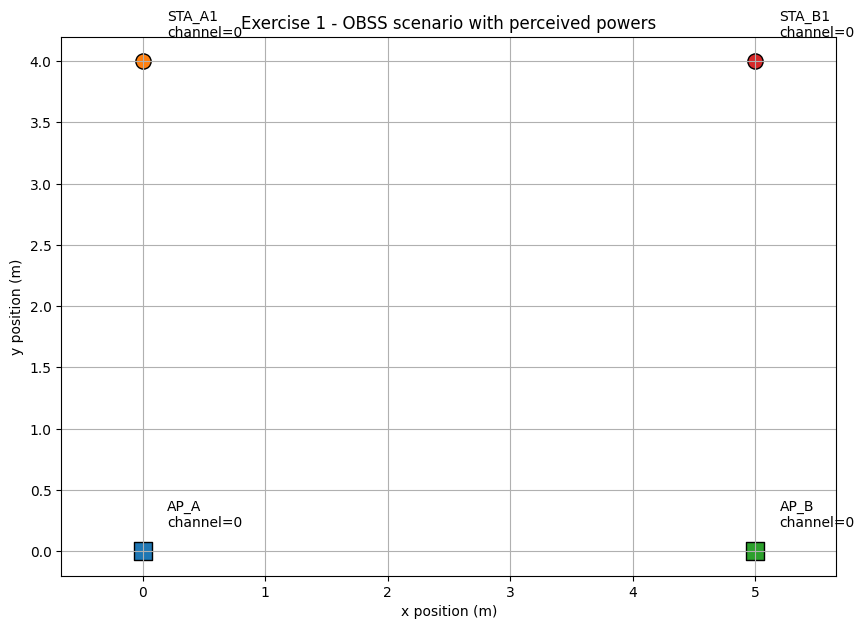

In [16]:
# Exercise 1 - Plot scenario

plt.figure(figsize=(10, 7))

if not powers_summary.empty:
    min_power = powers_summary['power_dbm'].min()
    max_power = powers_summary['power_dbm'].max()

    for _, row in powers_summary.iterrows():
        tx_row = nodes[nodes['node_name'] == row['transmitter']].iloc[0]
        rx_row = nodes[nodes['node_name'] == row['receiver']].iloc[0]

        x_tx, y_tx = tx_row[col_x], tx_row[col_y]
        x_rx, y_rx = rx_row[col_x], rx_row[col_y]
        power = row['power_dbm']

        if max_power != min_power:
            normalized_power = (power - min_power) / (max_power - min_power)
        else:
            normalized_power = 0.5

        plt.plot(
            [x_tx, x_rx],
            [y_tx, y_rx],
            linestyle='--',
            linewidth=0.5 + 3 * normalized_power,
            alpha=0.25 + 0.55 * normalized_power
        )
        plt.text(
            (x_tx + x_rx) / 2,
            (y_tx + y_rx) / 2,
            f'{power:.1f} dBm',
            fontsize=8,
            ha='center',
            va='center'
        )

for _, row in nodes.iterrows():
    node_name = row['node_name']
    marker = 's' if 'AP' in node_name else 'o'
    size = 180 if 'AP' in node_name else 120

    plt.scatter(row[col_x], row[col_y], s=size, marker=marker, edgecolor='black')
    plt.text(row[col_x] + 0.2, row[col_y] + 0.2, f'{node_name}\nchannel={row["channel_used"]}', fontsize=10)

plt.title('Exercise 1 - OBSS scenario with perceived powers')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.grid(True)
plt.axis('equal')
plt.show()

#### Exercise 1 analysis

The first simulation is the reference case without learning agents. The APs and STAs are correctly loaded from `input_nodes.csv`, and the node logs allow us to check the perceived power between devices. This is useful before using learning agents because it confirms that the topology and the sensing relationships are coherent.

The figure represents the physical scenario and the perceived power values extracted from the logs. Stronger links correspond to nodes that are closer or that receive a higher signal level. This step is mainly a validation step: if the powers or node positions were wrong, the learning results later in the lab would not be meaningful.

### Exercise 2

Run the simulator with agents in monitoring mode. Here, the agents do not optimize the channel yet; they only record temporary throughput values from their associated APs.

In [17]:
# Exercise 2 - Run monitoring agents

INPUT_FILE_NODES = '../input/input_nodes.csv'
INPUT_FILE_AGENTS = '../input/agents_monitoring.csv'
OUTPUT_FILE_LOGS = '../output/logs_exercise2_agents.txt'
SIMULATION_CODE = 'AAX-LAB1-EX2-AGENTS'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0
FLAG_PRINT_AGENT_LOGS = 0

SIM_TIME = 100
SEED = 7

!cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_exercise2_agents.txt
  - simulation_code: AAX-LAB1-EX2-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX2-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating 

,mechanism,ap,time,throughput
0,monitoring,AP_A,0.5,21.43
1,monitoring,AP_A,1.0,21.43
2,monitoring,AP_A,1.5,19.61
3,monitoring,AP_A,2.0,22.80
4,monitoring,AP_A,2.5,20.52


,ap,count
0,AP_A,199
1,AP_B,199


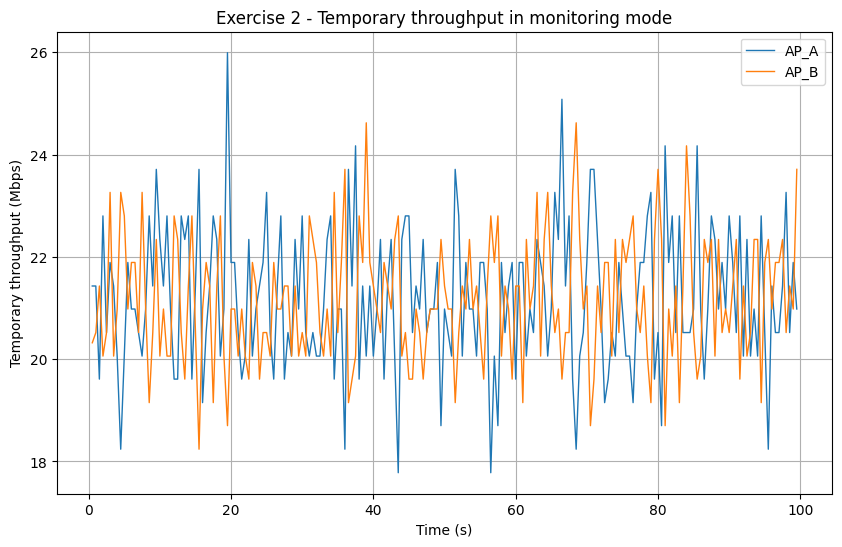

In [18]:
# Exercise 2 - Extract and plot temporary throughput

# Monitoring logs are written once per agent. The wildcard A*.txt catches AP_A and AP_B logs.
exercise2_logs = sorted(glob.glob(os.path.join(output_path, 'logs_output_AAX-LAB1-EX2-AGENTS_A*.txt')))

# Build a clean dataframe with one row per time step and AP.
monitoring_df = extract_agent_throughput(exercise2_logs, 'monitoring')

display(monitoring_df.head())
display(monitoring_df.groupby('ap').size().reset_index(name='count'))

# Plot the temporary throughput curves. This shows the network behavior over time.
plt.figure(figsize=(10, 6))
for ap_name in monitoring_df['ap'].unique():
    ap_data = monitoring_df[monitoring_df['ap'] == ap_name]
    plt.plot(ap_data['time'], ap_data['throughput'], linewidth=1, label=ap_name)

plt.title('Exercise 2 - Temporary throughput in monitoring mode')
plt.xlabel('Time (s)')
plt.ylabel('Temporary throughput (Mbps)')
plt.grid(True)
plt.legend()
plt.show()

#### Exercise 2 analysis

In monitoring mode, the agents observe the network but do not really optimize the channel selection. The extraction found 199 temporary throughput values for each AP, which is coherent with a 100 s simulation and a request period of 0.5 s.

The first values are around 20--22 Mbps for `AP_A`, but the goal here is not to maximize throughput yet. This exercise mainly checks that the agent logs are readable and that the temporary throughput metric can be extracted correctly. This dataframe is then reused as the baseline format for the learning mechanisms.

### Exercise 3

Create `agents_egreedy.csv`, enable the MAB mechanism, set the strategy to epsilon-greedy, and allow both channel actions `0,1`.

In [19]:
# Exercise 3 - Create epsilon-greedy agents file

agents_monitoring_path = os.path.join(input_path, 'agents_monitoring.csv')
agents_egreedy_path = os.path.join(input_path, 'agents_egreedy.csv')

agents_df = pd.read_csv(agents_monitoring_path, sep=';')
agents_df.columns = [col.strip() for col in agents_df.columns]

col_actions = find_exact_or_contains_column(agents_df, exact_names=['actions channels'])
col_learning = find_exact_or_contains_column(agents_df, exact_names=['learning mechanism'])
col_strategy = find_exact_or_contains_column(agents_df, exact_names=['selected_strategy'], contains_names=['selected strategy'])

agents_egreedy = agents_df.copy()
agents_egreedy[col_actions] = '0,1'
agents_egreedy[col_learning] = 1
agents_egreedy[col_strategy] = 1

agents_egreedy.to_csv(agents_egreedy_path, sep=';', index=False)
display(agents_egreedy)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1


In [20]:
# Exercise 3 - Run epsilon-greedy simulation

INPUT_FILE_NODES = '../input/input_nodes.csv'
INPUT_FILE_AGENTS = '../input/agents_egreedy.csv'
OUTPUT_FILE_LOGS = '../output/logs_exercise3_egreedy.txt'
SIMULATION_CODE = 'AAX-LAB1-EX3-EGREEDY'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

!cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy.csv
  - script_output_filename: ../output/logs_exercise3_egreedy.txt
  - simulation_code: AAX-LAB1-EX3-EGREEDY
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX3-EGREEDY.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating 

,mechanism,ap,time,throughput
0,epsilon-greedy,AP_A,0.5,21.43
1,epsilon-greedy,AP_A,1.0,22.34
2,epsilon-greedy,AP_A,1.5,39.67
3,epsilon-greedy,AP_A,2.0,39.22
4,epsilon-greedy,AP_A,2.5,39.67


,ap,count
0,AP_A,199
1,AP_B,199


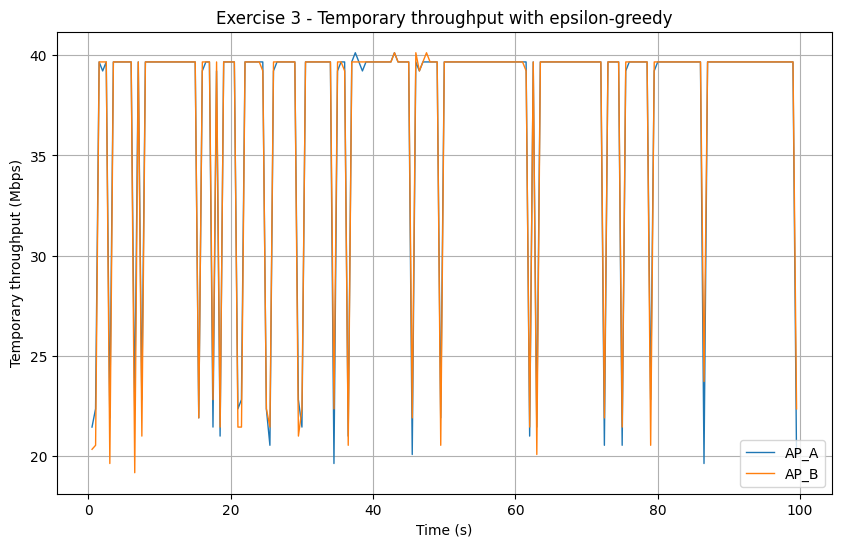

In [21]:
# Exercise 3 - Extract epsilon-greedy temporary throughput

# These are the logs generated by the agents after enabling the MAB mechanism.
egreedy_logs = sorted(glob.glob(os.path.join(output_path, 'logs_output_AAX-LAB1-EX3-EGREEDY_A*.txt')))
egreeedy_mechanism_name = 'epsilon-greedy'

# Extract the same metric as in Exercise 2, so the comparison is fair.
egreedy_df = extract_agent_throughput(egreedy_logs, egreeedy_mechanism_name)

display(egreedy_df.head())
display(egreedy_df.groupby('ap').size().reset_index(name='count'))

# The curve should react quickly because epsilon-greedy starts exploring/exploiting actions.
plt.figure(figsize=(10, 6))
for ap_name in egreedy_df['ap'].unique():
    ap_data = egreedy_df[egreedy_df['ap'] == ap_name]
    plt.plot(ap_data['time'], ap_data['throughput'], linewidth=1, label=ap_name)

plt.title('Exercise 3 - Temporary throughput with epsilon-greedy')
plt.xlabel('Time (s)')
plt.ylabel('Temporary throughput (Mbps)')
plt.grid(True)
plt.legend()
plt.show()

#### Exercise 3 analysis

The epsilon-greedy configuration is correctly loaded when the console shows `learning_mechanism: 1` and `action_selection_strategy: 1`. The extracted logs again contain 199 throughput values per AP, so the comparison with monitoring mode is done on the same time resolution.

Compared with the first monitoring values, the epsilon-greedy curve quickly reaches values close to 39 Mbps on `AP_A`. This is expected: the agent sometimes explores other actions, but it mostly exploits the best action found so far. The resulting curve is therefore less passive than monitoring mode and shows the beginning of channel adaptation.

### Exercise 4

Create the `agents_ml4net.csv` file and implement a custom strategy in `PickArmML4Net()`. The selected strategy is set to 5.

In [22]:
# Exercise 4 - Create ML4Net agents file

agents_ml4net_path = os.path.join(input_path, 'agents_ml4net.csv')

agents_ml4net = agents_df.copy()
agents_ml4net[col_actions] = '0,1'
agents_ml4net[col_learning] = 1
agents_ml4net[col_strategy] = 5

agents_ml4net.to_csv(agents_ml4net_path, sep=';', index=False)
display(agents_ml4net)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,5
1,B,0,0.5,"0,1",-82,15,1,2,1,5


In [23]:
# Exercise 4 - Replace PickArmML4Net by a simple UCB-like strategy

mab_path = os.path.join(base_path, 'learning_modules', 'network_optimization_methods', 'multi_armed_bandits.h')
backup_path = mab_path + '.backup'

if not os.path.exists(backup_path):
    shutil.copy(mab_path, backup_path)

with open(mab_path, 'r', errors='ignore') as f:
    code_text = f.read()

pattern = r'int\s+PickArmML4Net\s*\(\s*int\s+num_arms\s*\)\s*\{'
match = re.search(pattern, code_text)

if match is None:
    raise ValueError('PickArmML4Net(int num_arms) was not found.')

start = match.start()
brace_start = code_text.find('{', match.end() - 1)
brace_count = 0
end = None

for i in range(brace_start, len(code_text)):
    if code_text[i] == '{':
        brace_count += 1
    elif code_text[i] == '}':
        brace_count -= 1
        if brace_count == 0:
            end = i + 1
            break

if end is None:
    raise ValueError('Could not find the end of PickArmML4Net().')

new_function = r"""int PickArmML4Net(int num_arms){

            /*
             * Custom ML4Net strategy.
             *
             * The strategy is inspired by UCB. It first tries each arm once.
             * Then it selects the arm with the largest score:
             *
             * score = estimated reward + exploration bonus
             *
             * This keeps a balance between exploiting good arms and testing
             * arms that have been selected less often.
             */

            int selected_arm = 0;

            for(int i = 0; i < num_arms; i++){
                if(times_arm_has_been_selected[i] == 0){
                    return i;
                }
            }

            double best_score = -999999999.0;

            for(int i = 0; i < num_arms; i++){

                double exploitation = estimated_reward_per_arm[i];
                double exploration = sqrt(
                    2.0 * log((double) num_iterations + 1.0)
                    / (double) times_arm_has_been_selected[i]
                );

                double score = exploitation + exploration;

                if(score > best_score){
                    best_score = score;
                    selected_arm = i;
                }
            }

            return selected_arm;
        }"""

code_text = code_text[:start] + new_function + code_text[end:]

with open(mab_path, 'w') as f:
    f.write(code_text)

print('PickArmML4Net() updated.')

PickArmML4Net() updated.


In [24]:
# Recompile after changing the C++ header

!cd "$mypath/main" && ./build_local

In [25]:
# Exercise 4 - Run ML4Net simulation

INPUT_FILE_NODES = '../input/input_nodes.csv'
INPUT_FILE_AGENTS = '../input/agents_ml4net.csv'
OUTPUT_FILE_LOGS = '../output/logs_exercise4_ml4net.txt'
SIMULATION_CODE = 'AAX-LAB1-EX4-ML4NET'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

!cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net.csv
  - script_output_filename: ../output/logs_exercise4_ml4net.txt
  - simulation_code: AAX-LAB1-EX4-ML4NET
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX4-ML4NET.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating node

#### Exercise 4 analysis

The custom ML4Net strategy uses an UCB-like score. Each action is tried at least once, then the selected action maximizes an exploitation term plus an exploration bonus. The idea is to avoid staying too early on a possibly suboptimal channel.

After editing the C++ header, recompilation is required; otherwise the simulator would still use the old strategy. The console confirms that `action_selection_strategy: 5` is used, which means the simulator is calling the custom ML4Net strategy.

### Exercise 5

Compare the temporary throughput obtained by epsilon-greedy and the custom ML4Net strategy.

,mechanism,ap,time,throughput
0,epsilon-greedy,AP_A,0.5,21.43
1,epsilon-greedy,AP_A,1.0,22.34
2,epsilon-greedy,AP_A,1.5,39.67
3,epsilon-greedy,AP_A,2.0,39.22
4,epsilon-greedy,AP_A,2.5,39.67


,mechanism,ap,count
0,ML4Net,AP_A,199
1,ML4Net,AP_B,199
2,epsilon-greedy,AP_A,199
3,epsilon-greedy,AP_B,199


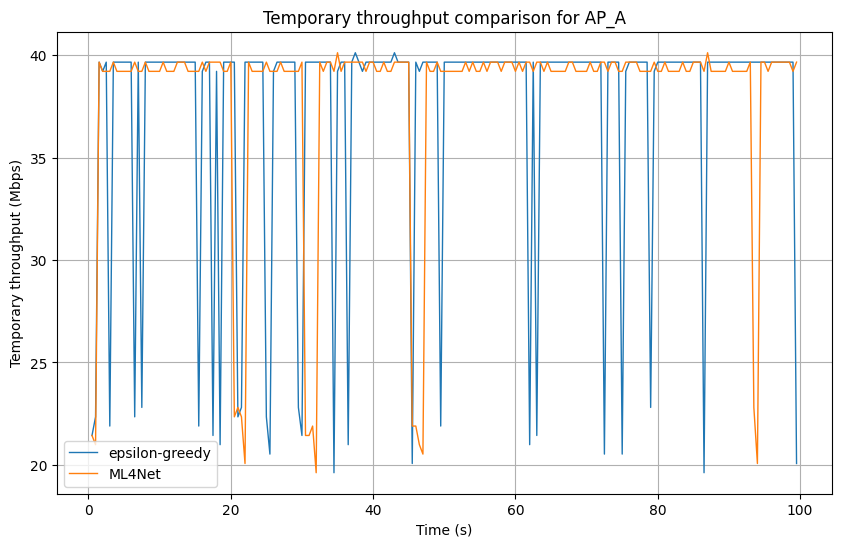

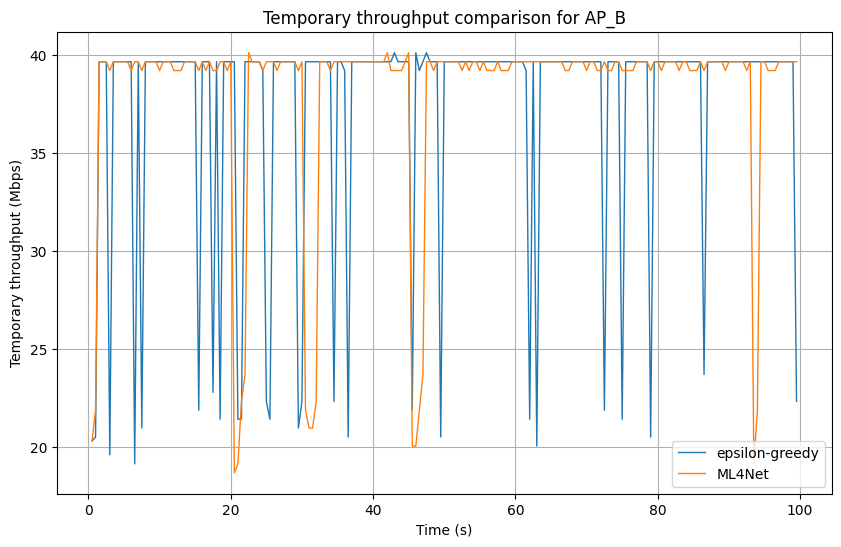

,mechanism,ap,throughput
0,ML4Net,AP_A,37.977538
1,ML4Net,AP_B,38.071357
2,epsilon-greedy,AP_A,37.363015
3,epsilon-greedy,AP_B,37.364121


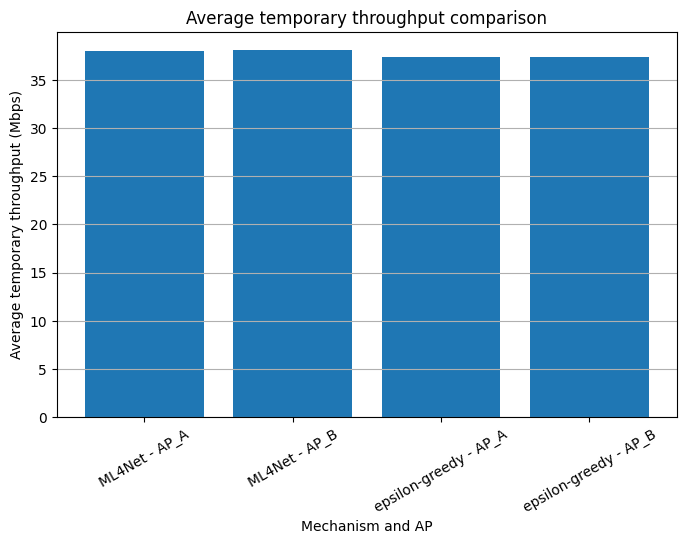

In [26]:
# Exercise 5 - Compare epsilon-greedy and ML4Net temporary throughput

# Load both sets of agent logs with the same extraction function.
egreedy_logs = sorted(glob.glob(os.path.join(output_path, 'logs_output_AAX-LAB1-EX3-EGREEDY_A*.txt')))
ml4net_logs = sorted(glob.glob(os.path.join(output_path, 'logs_output_AAX-LAB1-EX4-ML4NET_A*.txt')))

egreedy_df = extract_agent_throughput(egreedy_logs, 'epsilon-greedy')
ml4net_df = extract_agent_throughput(ml4net_logs, 'ML4Net')
comparison_df = pd.concat([egreedy_df, ml4net_df], ignore_index=True)

# Quick sanity checks: we expect the same number of time samples per mechanism and AP.
display(comparison_df.head())
display(comparison_df.groupby(['mechanism', 'ap']).size().reset_index(name='count'))

# One plot per AP makes the curves easier to read.
for ap_name in comparison_df['ap'].unique():
    plt.figure(figsize=(10, 6))
    ap_data = comparison_df[comparison_df['ap'] == ap_name]

    for mechanism in ap_data['mechanism'].unique():
        data = ap_data[ap_data['mechanism'] == mechanism]
        plt.plot(data['time'], data['throughput'], linewidth=1, label=mechanism)

    plt.title(f'Temporary throughput comparison for {ap_name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Temporary throughput (Mbps)')
    plt.grid(True)
    plt.legend()
    plt.show()

# Mean temporary throughput gives a compact numerical comparison.
average_comparison = comparison_df.groupby(['mechanism', 'ap'], as_index=False)['throughput'].mean()
display(average_comparison)

plt.figure(figsize=(8, 5))
labels = average_comparison['mechanism'] + ' - ' + average_comparison['ap']
plt.bar(labels, average_comparison['throughput'])
plt.title('Average temporary throughput comparison')
plt.xlabel('Mechanism and AP')
plt.ylabel('Average temporary throughput (Mbps)')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()

#### Comparison between epsilon-greedy and ML4Net

Both mechanisms are now compared using the same temporary throughput metric. The extraction gives 199 values for each pair `(mechanism, AP)`, so the comparison is balanced.

On the two-BSS scenario, ML4Net is slightly better on average: about **37.98 Mbps** for `AP_A` and **38.07 Mbps** for `AP_B`, compared with about **37.36 Mbps** for both APs with epsilon-greedy. The difference is not huge, but it suggests that the custom strategy explores the action space in a useful way and avoids some of the early greedy behavior.

The curve plots are important because the mean alone does not show the learning dynamics. Here, both methods stabilize at high throughput, but ML4Net gives a slightly higher average temporary throughput over the simulation.

### Exercise 6

In this exercise, we extend the topology by adding a third BSS. The new BSS is placed on the right side of the previous two, with `AP_C` at `(10,0,0)` and `STA_C1` at `(10,4,0)`.

The objective is then to compare two action-selection strategies, epsilon-greedy and ML4Net, over five random seeds. For each strategy and each seed, we extract the final throughput of `AP_A`, `AP_B`, and `AP_C`, then compute the average performance across seeds.

In [27]:
# Exercise 6 - Create input_nodes_3bss.csv

# Original node file and new file used for the three-BSS scenario.
input_nodes_path = os.path.join(input_path, 'input_nodes.csv')
input_nodes_3bss_path = os.path.join(input_path, 'input_nodes_3bss.csv')

# Read the original node configuration.
nodes_df = read_csv_auto(input_nodes_path)
nodes_df.columns = [col.strip() for col in nodes_df.columns]

# Find the important columns safely.
# Exact names are used first to avoid confusing y(m) with node_type.
col_node_code = find_exact_or_contains_column(nodes_df, exact_names=['node_code'])
col_node_type = find_exact_or_contains_column(nodes_df, exact_names=['node_type'])
col_wlan_code = find_exact_or_contains_column(nodes_df, exact_names=['wlan_code'])
col_x = find_exact_or_contains_column(nodes_df, exact_names=['x(m)'], contains_names=['x'])
col_y = find_exact_or_contains_column(nodes_df, exact_names=['y(m)'], contains_names=['y'])
col_z = find_exact_or_contains_column(nodes_df, exact_names=['z(m)'], contains_names=['z'])

# Start from the original topology and remove any previous C nodes if the cell was run before.
nodes_3bss = nodes_df.copy()
nodes_3bss = nodes_3bss[~nodes_3bss[col_wlan_code].astype(str).str.strip().eq('C')]

# Use BSS B as a template because it already has one AP and one STA with the right configuration.
ap_template = nodes_df[nodes_df[col_node_code].astype(str).str.contains('AP_B', case=False, na=False)].iloc[0].copy()
sta_template = nodes_df[nodes_df[col_node_code].astype(str).str.contains('STA_B1', case=False, na=False)].iloc[0].copy()

# Create the new access point AP_C.
ap_c = ap_template.copy()
ap_c[col_node_code] = 'AP_C'
ap_c[col_node_type] = 0       # 0 = AP
ap_c[col_wlan_code] = 'C'
ap_c[col_x] = 10
ap_c[col_y] = 0
ap_c[col_z] = 0

# Create the new station STA_C1.
sta_c = sta_template.copy()
sta_c[col_node_code] = 'STA_C1'
sta_c[col_node_type] = 1      # 1 = STA. This is important; type 4 caused the simulation to fail.
sta_c[col_wlan_code] = 'C'
sta_c[col_x] = 10
sta_c[col_y] = 4
sta_c[col_z] = 0

# Save the new topology file.
nodes_3bss = pd.concat([nodes_3bss, pd.DataFrame([ap_c, sta_c])], ignore_index=True)
nodes_3bss.to_csv(input_nodes_3bss_path, sep=';', index=False)

# Display the result to quickly check that WLAN C has one AP and one STA.
display(nodes_3bss)


,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
0,AP_A,0,A,0,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
1,STA_A1,1,A,0,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
2,AP_B,0,B,5,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
3,STA_B1,1,B,5,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
4,AP_C,0,C,10,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
5,STA_C1,1,C,10,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


In [28]:
# Exercise 6 - Create three-agent files for both strategies

# Output agent files for the two strategies tested in Exercise 6.
agents_egreedy_3bss_path = os.path.join(input_path, 'agents_egreedy_3bss.csv')
agents_ml4net_3bss_path = os.path.join(input_path, 'agents_ml4net_3bss.csv')

# Start from the monitoring agent file because it already has the correct general structure.
agents_df = pd.read_csv(agents_monitoring_path, sep=';')
agents_df.columns = [col.strip() for col in agents_df.columns]

# Locate the columns that must be edited.
col_wlan_agent = find_exact_or_contains_column(agents_df, exact_names=['Wlan code'], contains_names=['wlan'])
col_actions = find_exact_or_contains_column(agents_df, exact_names=['actions channels'])
col_learning = find_exact_or_contains_column(agents_df, exact_names=['learning mechanism'])
col_strategy = find_exact_or_contains_column(agents_df, exact_names=['selected_strategy'], contains_names=['selected strategy'])

# Remove any previous C agent, then duplicate the B agent and rename it C.
# This enrolls the third BSS into the learning process.
agents_base_3bss = agents_df.copy()
agents_base_3bss = agents_base_3bss[agents_base_3bss[col_wlan_agent].astype(str).str.strip() != 'C']

agent_c = agents_df[agents_df[col_wlan_agent].astype(str).str.strip() == 'B'].iloc[0].copy()
agent_c[col_wlan_agent] = 'C'
agents_base_3bss = pd.concat([agents_base_3bss, pd.DataFrame([agent_c])], ignore_index=True)

# Epsilon-greedy: learning mechanism 1 and selected strategy 1.
agents_egreedy_3bss = agents_base_3bss.copy()
agents_egreedy_3bss[col_actions] = '0,1'
agents_egreedy_3bss[col_learning] = 1
agents_egreedy_3bss[col_strategy] = 1

# ML4Net strategy: same learning mechanism, but selected strategy 5.
agents_ml4net_3bss = agents_base_3bss.copy()
agents_ml4net_3bss[col_actions] = '0,1'
agents_ml4net_3bss[col_learning] = 1
agents_ml4net_3bss[col_strategy] = 5

# Save both input files.
agents_egreedy_3bss.to_csv(agents_egreedy_3bss_path, sep=';', index=False)
agents_ml4net_3bss.to_csv(agents_ml4net_3bss_path, sep=';', index=False)

# Display them to verify that A, B and C are all present.
display(agents_egreedy_3bss)
display(agents_ml4net_3bss)


,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1
2,C,0,0.5,"0,1",-82,15,1,2,1,1


,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,5
1,B,0,0.5,"0,1",-82,15,1,2,1,5
2,C,0,0.5,"0,1",-82,15,1,2,1,5


In [29]:
# Exercise 6 - Run five seeds for each mechanism

# Remove previous EX6 files to avoid mixing old failed runs with the corrected ones.
# This is especially useful after fixing the STA_C1 node type.
for file in glob.glob(os.path.join(output_path, '*AAX-LAB1-EX6*')):
    os.remove(file)

# Five seeds requested in the statement.
seeds = [7, 13, 21, 42, 100]

# Each configuration corresponds to one action-selection strategy.
simulation_configs = [
    {
        'mechanism': 'epsilon-greedy',
        'agents_file': '../input/agents_egreedy_3bss.csv',
        'code_prefix': 'AAX-LAB1-EX6-EGREEDY'
    },
    {
        'mechanism': 'ML4Net',
        'agents_file': '../input/agents_ml4net_3bss.csv',
        'code_prefix': 'AAX-LAB1-EX6-ML4NET'
    }
]

# Common Komondor arguments.
INPUT_FILE_NODES = '../input/input_nodes_3bss.csv'
FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1      # Must be 1 to print the final AP throughput blocks.
FLAG_PRINT_AGENT_LOGS = 0
SIM_TIME = 100

for config in simulation_configs:
    print('\n==============================')
    print('Running mechanism:', config['mechanism'])
    print('==============================')

    for seed in seeds:
        print('\nRunning seed:', seed)

        # The simulation code is unique for each strategy and seed.
        # This makes the generated log files easy to identify afterwards.
        INPUT_FILE_AGENTS = config['agents_file']
        SIMULATION_CODE = config['code_prefix'] + '-SEED-' + str(seed)
        OUTPUT_FILE_LOGS = '../output/logs_' + SIMULATION_CODE + '.txt'
        SEED = seed

        !cd "$mypath/main" && ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED



Running mechanism: epsilon-greedy

Running seed: 7

*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_3bss.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy_3bss.csv
  - script_output_filename: ../output/logs_AAX-LAB1-EX6-EGREEDY-SEED-7.txt
  - simulation_code: AAX-LAB1-EX6-EGREEDY-SEED-7
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX6-EGREEDY-SEED-7.txt' created!

 Reading system confi

In [52]:
# Exercise 6 - Extract final AP throughputs from the console log files

# The dictionary maps the readable strategy name to the file prefix used by Komondor.
mechanisms = {
    'epsilon-greedy': 'AAX-LAB1-EX6-EGREEDY',
    'ML4Net': 'AAX-LAB1-EX6-ML4NET'
}

# Extract one final throughput value per mechanism, seed and BSS.
# The corrected function searches both output folders, including main/output.
results_df = extract_ex6_final_results(output_roots, mechanisms, seeds)

display(results_df)

if results_df.empty:
    print('No throughput values were extracted.')
    print('Check both folders:')
    for root in output_roots:
        print(' -', root)
else:
    print('Number of extracted values per mechanism and BSS:')
    display(results_df.groupby(['mechanism', 'bss']).size().reset_index(name='count'))

,mechanism,seed,bss,ap,throughput_mbps
0,epsilon-greedy,7,BSS A,AP_A,38.25840
1,epsilon-greedy,7,BSS B,AP_B,34.24104
2,epsilon-greedy,7,BSS C,AP_C,38.17404
3,epsilon-greedy,13,BSS A,AP_A,38.07828
4,epsilon-greedy,13,BSS B,AP_B,35.28984
5,epsilon-greedy,13,BSS C,AP_C,38.36100
6,epsilon-greedy,21,BSS A,AP_A,38.11932
7,epsilon-greedy,21,BSS B,AP_B,35.29668
8,epsilon-greedy,21,BSS C,AP_C,38.52516
9,epsilon-greedy,42,BSS A,AP_A,38.48412


Number of extracted values per mechanism and BSS:


,mechanism,bss,count
0,ML4Net,BSS A,5
1,ML4Net,BSS B,5
2,ML4Net,BSS C,5
3,epsilon-greedy,BSS A,5
4,epsilon-greedy,BSS B,5
5,epsilon-greedy,BSS C,5


,mechanism,bss,throughput_mbps
0,ML4Net,BSS A,37.246536
1,ML4Net,BSS B,33.292560
2,ML4Net,BSS C,37.186344
3,epsilon-greedy,BSS A,38.240160
4,epsilon-greedy,BSS B,34.899048
5,epsilon-greedy,BSS C,38.292600


,index,mechanism,bss,mean,std,min,max
0,0,ML4Net,BSS A,37.246536,1.327132,35.98296,38.82612
1,1,ML4Net,BSS B,33.292560,3.240093,29.87484,36.61452
2,2,ML4Net,BSS C,37.186344,0.907703,35.97840,38.06916
3,3,epsilon-greedy,BSS A,38.240160,0.158964,38.07828,38.48412
4,4,epsilon-greedy,BSS B,34.899048,0.436549,34.24104,35.29668
5,5,epsilon-greedy,BSS C,38.292600,0.162225,38.11248,38.52516


,mechanism,seed,total_throughput_mbps
0,ML4Net,7,108.61920
1,ML4Net,13,112.28772
2,ML4Net,21,113.27724
3,ML4Net,42,101.83620
4,ML4Net,100,102.60684
5,epsilon-greedy,7,110.67348
6,epsilon-greedy,13,111.72912
7,epsilon-greedy,21,111.94116
8,epsilon-greedy,42,111.67896
9,epsilon-greedy,100,111.13632


,index,mechanism,mean,std,min,max
0,0,ML4Net,107.725440,5.322568,101.83620,113.27724
1,1,epsilon-greedy,111.431808,0.517516,110.67348,111.94116


mechanism,ML4Net,epsilon-greedy
bss,,
BSS A,37.246536,38.240160
BSS B,33.292560,34.899048
BSS C,37.186344,38.292600


,bss,epsilon_minus_ml4net_mbps
0,BSS A,0.993624
1,BSS B,1.606488
2,BSS C,1.106256


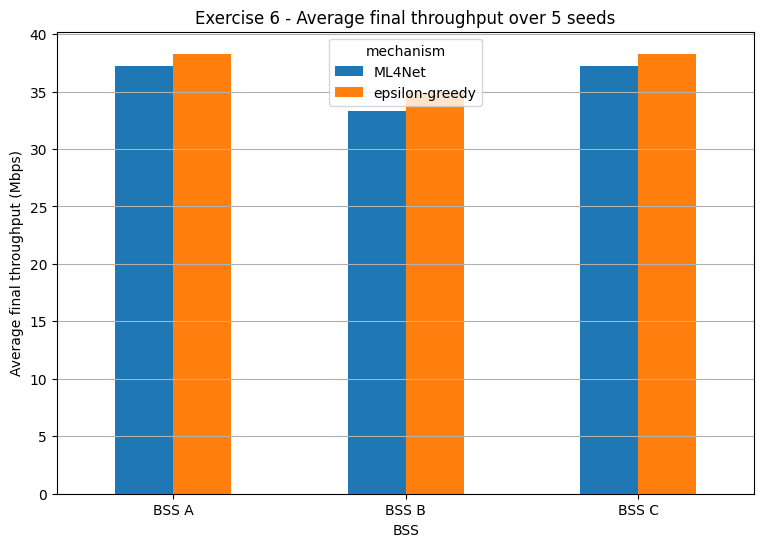

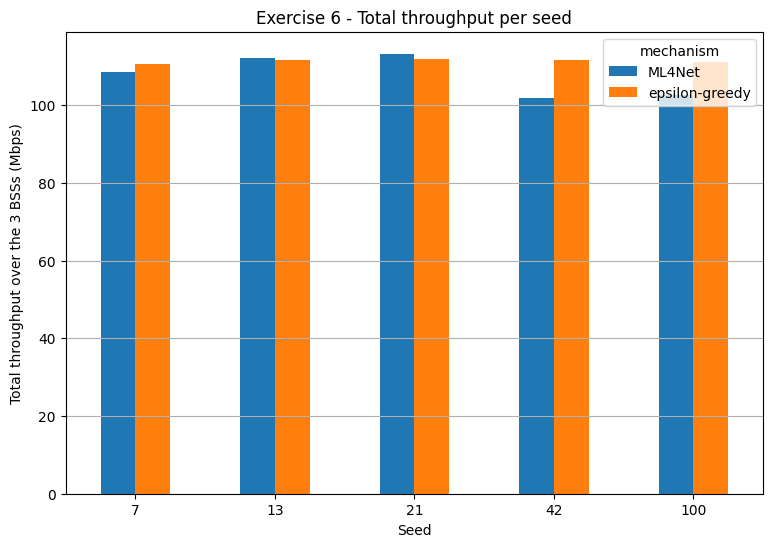

In [53]:
# Exercise 6 - Quantitative summary and plots

if not results_df.empty:
    # Mean throughput per strategy and BSS.
    average_results = (
        results_df
        .groupby(['mechanism', 'bss'], as_index=False)['throughput_mbps']
        .mean()
    )

    # Stability across seeds: std/min/max are important because one seed can be misleading.
    summary_results = (
        results_df
        .groupby(['mechanism', 'bss'], as_index=False)['throughput_mbps']
        .agg(['mean', 'std', 'min', 'max'])
        .reset_index()
    )

    # Total network throughput for each seed, then average total throughput by mechanism.
    total_per_seed = (
        results_df
        .groupby(['mechanism', 'seed'], as_index=False)['throughput_mbps']
        .sum()
        .rename(columns={'throughput_mbps': 'total_throughput_mbps'})
    )

    total_summary = (
        total_per_seed
        .groupby('mechanism', as_index=False)['total_throughput_mbps']
        .agg(['mean', 'std', 'min', 'max'])
        .reset_index()
    )

    display(average_results)
    display(summary_results)
    display(total_per_seed)
    display(total_summary)

    # Pivot table used for the grouped bar plot.
    pivot_results = average_results.pivot(index='bss', columns='mechanism', values='throughput_mbps')
    display(pivot_results)

    # Difference between both strategies for each BSS.
    # Positive values mean epsilon-greedy is better on average.
    if {'epsilon-greedy', 'ML4Net'}.issubset(set(pivot_results.columns)):
        delta_results = pivot_results['epsilon-greedy'] - pivot_results['ML4Net']
        delta_results = delta_results.reset_index(name='epsilon_minus_ml4net_mbps')
        display(delta_results)

    # Main plot requested by the exercise.
    pivot_results.plot(kind='bar', figsize=(9, 6))
    plt.title('Exercise 6 - Average final throughput over 5 seeds')
    plt.xlabel('BSS')
    plt.ylabel('Average final throughput (Mbps)')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()

    # Extra plot: total throughput per seed, useful to see the stability of each strategy.
    total_pivot = total_per_seed.pivot(index='seed', columns='mechanism', values='total_throughput_mbps')
    total_pivot.plot(kind='bar', figsize=(9, 6))
    plt.title('Exercise 6 - Total throughput per seed')
    plt.xlabel('Seed')
    plt.ylabel('Total throughput over the 3 BSSs (Mbps)')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()
else:
    print('Summary and plots skipped because results_df is empty.')

#### Exercise 6 quantitative analysis

The three-BSS scenario is more difficult because a third WLAN is added on the right side of the topology. The corrected extraction reads the final AP reports from the console logs and gives 5 values per mechanism and per BSS, one for each seed.

The average final throughputs are:

| BSS | epsilon-greedy | ML4Net | difference eps - ML4Net |
|---|---:|---:|---:|
| BSS A | 38.24 Mbps | 37.25 Mbps | +0.99 Mbps |
| BSS B | 34.90 Mbps | 33.29 Mbps | +1.61 Mbps |
| BSS C | 38.29 Mbps | 37.19 Mbps | +1.11 Mbps |

The total throughput is also higher and much more stable with epsilon-greedy: about **111.43 Mbps** on average, compared with **107.73 Mbps** for ML4Net. The standard deviation is also much lower for epsilon-greedy, about **0.52 Mbps** against **5.32 Mbps** for ML4Net. This means that, in this three-BSS setup, epsilon-greedy is not only slightly better on average, but also more reliable across the tested seeds.

The main reason is visible in the per-seed totals: ML4Net performs well for some seeds, especially 13 and 21, but drops strongly for seeds 42 and 100. Therefore, the custom strategy is more sensitive to random initialization/exploration in this denser scenario. Epsilon-greedy gives a more consistent allocation between the three BSSs.